<a href="https://colab.research.google.com/github/malhotrax/tensorflow/blob/main/MNIST_Hand_Written_Digit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import random

In [17]:
mnist = keras.datasets.mnist
data = mnist.load_data()

In [18]:
keras.utils.set_random_seed(42)
np.random.seed(42)

In [19]:
(x_train, y_train), (x_test, y_test) = data

In [20]:
x_train.shape

(60000, 28, 28)

In [21]:
random_indices = np.random.randint(0, len(x_train) - 1, size = 6)
random_indices

array([56422, 15795,   860, 38158, 54343, 44732])

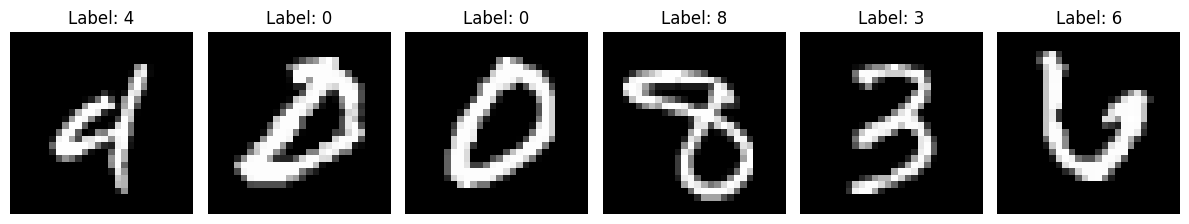

In [22]:
fig, axes = plt.subplots(nrows= 1, ncols= 6, figsize = (12,8) )
for i, idx in enumerate(random_indices):
    axs = axes[i]
    axs.imshow(x_train[idx], cmap = 'gray')
    axs.set_title(f"Label: {y_train[idx]}")
    axs.axis('off')
plt.tight_layout()
plt.show()

In [23]:
print(f"Training dataset size: {x_train.shape}")
sample_data = tf.expand_dims(x_train[0], axis = 0)
flatten_array = keras.layers.Flatten()(sample_data)
print(f"Sample data shape: {sample_data.shape}")
print(f"Flattening sample data shape: {flatten_array.shape}")
print(flatten_array)

Training dataset size: (60000, 28, 28)
Sample data shape: (1, 28, 28)
Flattening sample data shape: (1, 784)
tf.Tensor(
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
  247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
  170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
    0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251 

In [24]:
y_train_df = pd.DataFrame(y_train)
y_train_df.value_counts()

,count
0,
1,6742
7,6265
3,6131
2,5958
9,5949
0,5923
6,5918
8,5851
4,5842


In [25]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [26]:
input = keras.Input(shape = (28,28))
flatten = keras.layers.Flatten()(input)
h = keras.layers.Dense(8, activation='relu')(flatten)
output = keras.layers.Dense(10, activation='softmax')(h)
model = keras.Model(input, output)

In [27]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,370 (24.88 KB)

 Trainable params: 6,370 (24.88 KB)

 Non-trainable params: 0 (0.00 B)

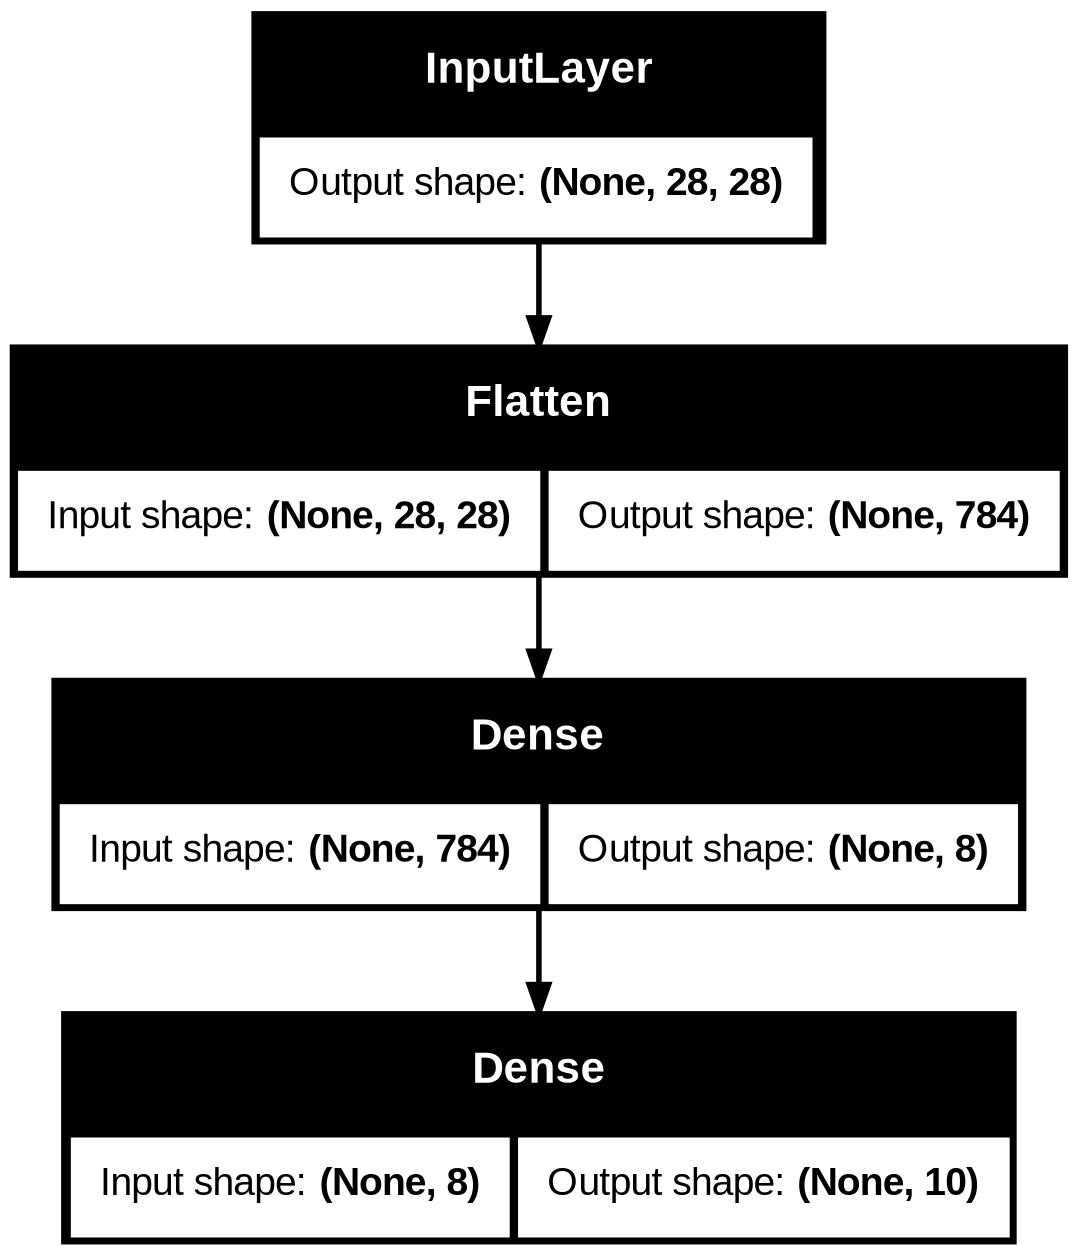

In [28]:
keras.utils.plot_model(model, show_shapes = True)

In [29]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [30]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=80,
    validation_split=0.1
)

Epoch 1/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8227 - loss: 0.6046 - val_accuracy: 0.9220 - val_loss: 0.2832
Epoch 2/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9064 - loss: 0.3304 - val_accuracy: 0.9272 - val_loss: 0.2499
Epoch 3/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9148 - loss: 0.3030 - val_accuracy: 0.9312 - val_loss: 0.2363
Epoch 4/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9191 - loss: 0.2881 - val_accuracy: 0.9352 - val_loss: 0.2291
Epoch 5/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9213 - loss: 0.2783 - val_accuracy: 0.9370 - val_loss: 0.2248
Epoch 6/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9235 - loss: 0.2707 - val_accuracy: 0.9390 - val_loss: 0.2219
Epoch 7/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9247 - loss: 0.2644 - val_accuracy: 0.9393 - val_loss: 0.2197
Epoch 8/80
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9263 - loss: 0.2594 - 

In [31]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

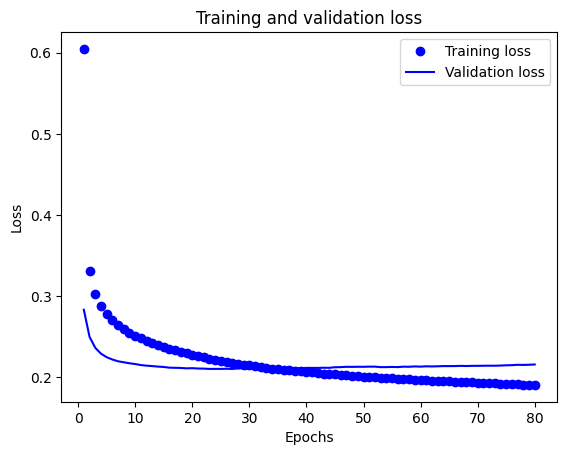

In [38]:
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


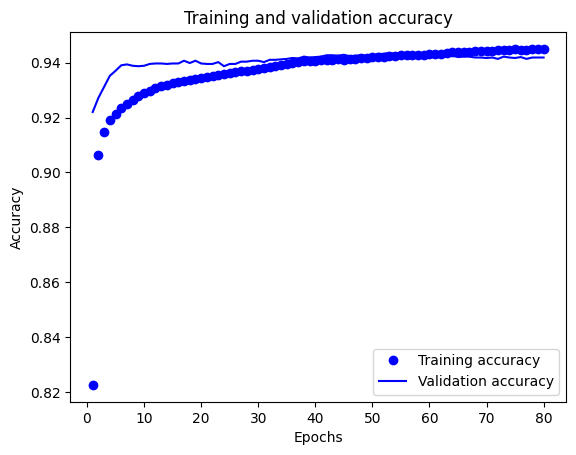

In [39]:
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [40]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9265 - loss: 0.2721


[0.2720952033996582, 0.9265000224113464]

In [43]:
idx = np.random.randint(0, len(x_test)-1)
data = tf.expand_dims(x_test[idx],0)
print(f"Acutal label: {y_test[idx]}")
model.predict(data)

Acutal label: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[4.4876498e-07, 5.3607533e-07, 6.6515768e-06, 1.1549732e-03,
        7.8506942e-05, 1.1189511e-04, 7.4886239e-06, 1.8842168e-07,
        9.9813962e-01, 4.9967936e-04]], dtype=float32)